In [1]:
import sys
from pathlib import Path

# Make src/ importable from notebook
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import ASSISTMENTS_FILE, REPORTS_DIR

print("Loading ASSISTments...")
df = pd.read_csv(ASSISTMENTS_FILE, encoding="ISO-8859-15", low_memory=False)
print("Shape:", df.shape)
df.head()

Loading ASSISTments...
Shape: (525534, 30)


,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,...,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,...,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,...,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,...,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,...,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,...,3,4,124564,30060,NaN,65,0,0.0,3,3.0


In [2]:
print("Columns:", list(df.columns))
print("\nDtypes:")
print(df.dtypes)
print("\nMissing values per column (top 15):")
print(df.isna().sum().sort_values(ascending=False).head(15))

Columns: ['order_id', 'assignment_id', 'user_id', 'assistment_id', 'problem_id', 'original', 'correct', 'attempt_count', 'ms_first_response', 'tutor_mode', 'answer_type', 'sequence_id', 'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id', 'skill_name', 'teacher_id', 'school_id', 'hint_count', 'hint_total', 'overlap_time', 'template_id', 'answer_id', 'answer_text', 'first_action', 'bottom_hint', 'opportunity', 'opportunity_original']

Dtypes:
order_id                  int64
assignment_id             int64
user_id                   int64
assistment_id             int64
problem_id                int64
original                  int64
correct                   int64
attempt_count             int64
ms_first_response         int64
tutor_mode               object
answer_type              object
sequence_id               int64
student_class_id          int64
position                  int64
type                     object
base_sequence_id          int64
skill_id               

In [3]:
# Columns we care about for learner-state modelling:
# user_id, problem_id, skill_id, skill_name, correct,
# attempt_count, hint_count, ms_first_response, order_id, original
needed = [
    "user_id", "problem_id", "skill_id", "skill_name",
    "correct", "attempt_count", "hint_count",
    "ms_first_response", "order_id", "original"
]
existing = [c for c in needed if c in df.columns]
print("Using columns:", existing)
df_small = df[existing].copy()
print("Shape after column selection:", df_small.shape)
df_small.head()

Using columns: ['user_id', 'problem_id', 'skill_id', 'skill_name', 'correct', 'attempt_count', 'hint_count', 'ms_first_response', 'order_id', 'original']
Shape after column selection: (525534, 10)


,user_id,problem_id,skill_id,skill_name,correct,attempt_count,hint_count,ms_first_response,order_id,original
0,64525,51424,1.0,Box and Whisker,1,1,0,32454,33022537,1
1,64525,51435,1.0,Box and Whisker,1,1,0,4922,33022709,1
2,70363,51444,1.0,Box and Whisker,0,2,0,25390,35450204,1
3,70363,51395,1.0,Box and Whisker,1,1,0,4859,35450295,1
4,70363,51481,1.0,Box and Whisker,0,14,3,19813,35450311,1


In [4]:
# Drop rows missing skill_id (multi-skill rows or noise)
df_small = df_small.dropna(subset=["skill_id", "user_id", "correct"])

# Cast types
df_small["correct"] = df_small["correct"].astype(int)
df_small["skill_id"] = df_small["skill_id"].astype(int)
df_small["user_id"] = df_small["user_id"].astype(int)

print("Total interactions:", len(df_small))
print("Unique students:", df_small["user_id"].nunique())
print("Unique skills:", df_small["skill_id"].nunique())
print("Overall accuracy:", df_small["correct"].mean().round(3))
print("\nHint count distribution:")
print(df_small["hint_count"].describe())
print("\nAttempt count distribution:")
print(df_small["attempt_count"].describe())

Total interactions: 459208
Unique students: 4163
Unique skills: 123
Overall accuracy: 0.69

Hint count distribution:
count    459208.000000
mean          0.397471
std           1.083330
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           7.000000
Name: hint_count, dtype: float64

Attempt count distribution:
count    459208.000000
mean          1.462320
std          11.092396
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        3824.000000
Name: attempt_count, dtype: float64


Interactions per student:
count    4163.00000
mean      110.30699
std       277.10220
min         1.00000
25%         9.00000
50%        24.00000
75%        82.00000
max      6157.00000
dtype: float64


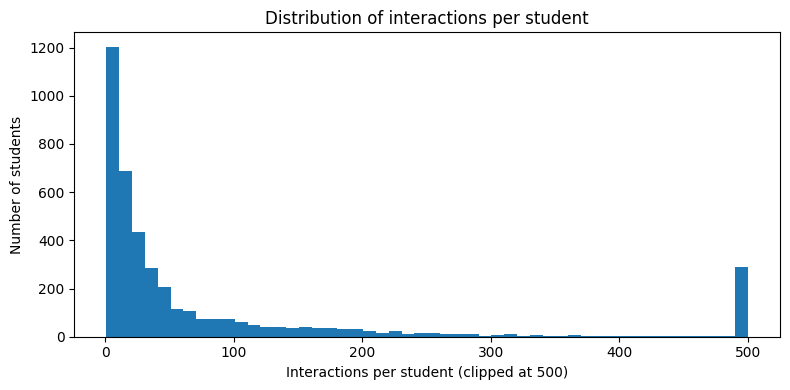

In [5]:
counts = df_small.groupby("user_id").size()
print("Interactions per student:")
print(counts.describe())

plt.figure(figsize=(8, 4))
plt.hist(counts.clip(upper=500), bins=50)
plt.xlabel("Interactions per student (clipped at 500)")
plt.ylabel("Number of students")
plt.title("Distribution of interactions per student")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "assistments_interactions_per_student.png", dpi=120)
plt.show()

In [6]:
skill_acc = df_small.groupby("skill_id")["correct"].agg(["mean", "count"])
skill_acc = skill_acc[skill_acc["count"] >= 50].sort_values("mean")
print("Hardest 5 skills:")
print(skill_acc.head())
print("\nEasiest 5 skills:")
print(skill_acc.tail())

Hardest 5 skills:
              mean  count
skill_id                 
292       0.135831    427
350       0.192308    234
299       0.315682    491
204       0.333333    117
166       0.367609    389

Easiest 5 skills:
              mean  count
skill_id                 
296       0.887119  12934
298       0.893809  10839
24        0.894378    587
32        0.950000    280
295       0.979537   3323


In [7]:
# Quick look at hint and attempt patterns when correct=0
fails = df_small[df_small["correct"] == 0]
succs = df_small[df_small["correct"] == 1]
print("On wrong answers:")
print("  mean hint_count:", fails["hint_count"].mean().round(2))
print("  mean attempt_count:", fails["attempt_count"].mean().round(2))
print("On right answers:")
print("  mean hint_count:", succs["hint_count"].mean().round(2))
print("  mean attempt_count:", succs["attempt_count"].mean().round(2))

On wrong answers:
  mean hint_count: 1.28
  mean attempt_count: 2.57
On right answers:
  mean hint_count: 0.0
  mean attempt_count: 0.97


In [8]:
from src.config import PROCESSED_DIR
out = PROCESSED_DIR / "assistments_slim.parquet"
df_small.to_parquet(out, index=False)
print("Saved slim version to:", out)
print("Rows:", len(df_small))

Saved slim version to: D:\Research\fapr-lb\data\processed\assistments_slim.parquet
Rows: 459208
